In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
import pandas as pd
import numpy as np

Métricas del modelo Naive Bayes:
Accuracy : 0.3405
Recall   : 0.1990
F1       : 0.0843
Instancias procesadas: 291200


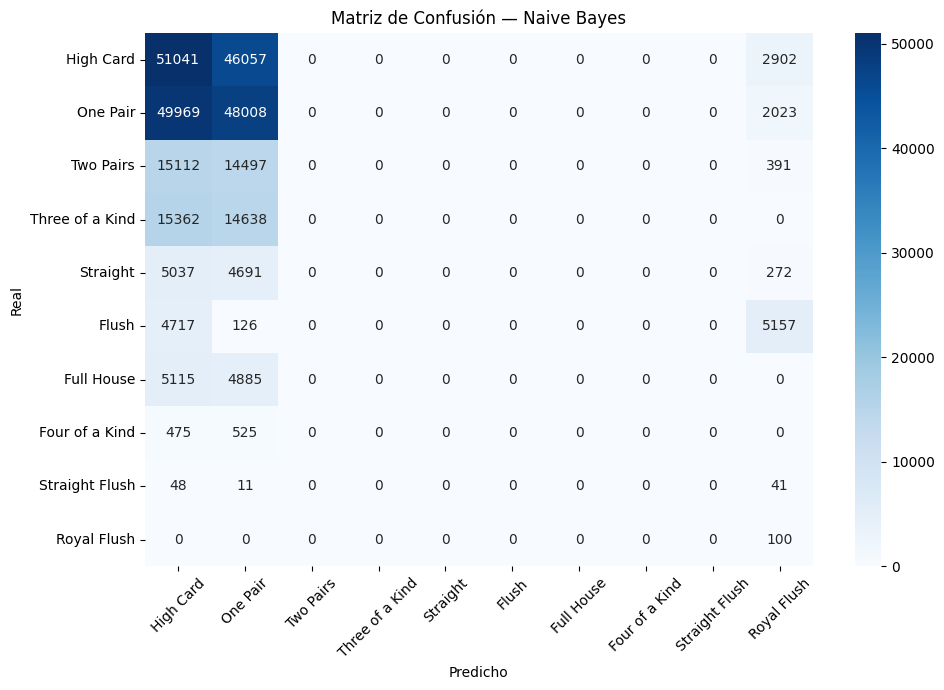

In [5]:
# 1. Cargar
df = pd.read_csv('../preprocesamiento/preprocessed_trainning.data', header=None)
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

clases = sorted(y.unique().astype(int).tolist())
clase_nombres = {
    0: "High Card", 1: "One Pair", 2: "Two Pairs", 3: "Three of a Kind",
    4: "Straight",  5: "Flush",   6: "Full House", 7: "Four of a Kind",
    8: "Straight Flush", 9: "Royal Flush"
}
nombres_ordenados = [clase_nombres[c] for c in clases]

# 2. GaussianNB
modelo_nb = GaussianNB()
modelo_nb.fit(x, y)
y_pred = modelo_nb.predict(x)

# 3. Métricas
print("Métricas del modelo Naive Bayes:")
print(f"Accuracy : {accuracy_score(y, y_pred):.4f}")
print(f"Recall   : {recall_score(y, y_pred, average='macro', zero_division=0):.4f}")
print(f"F1       : {f1_score(y, y_pred, average='macro', zero_division=0):.4f}")
print("Instancias procesadas:", len(y))

# 4. Matriz de confusión
cm_nb = confusion_matrix(y, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_nb, annot=True, fmt='d', cmap='Blues',
    xticklabels=nombres_ordenados,
    yticklabels=nombres_ordenados,
)
plt.title("Matriz de Confusión — Naive Bayes")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tick_params(axis='x', rotation=45)
plt.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,074 (15.91 KB)

 Trainable params: 4,074 (15.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 7s 896us/step - accuracy: 0.4718 - loss: 1.0326 - val_accuracy: 0.0000e+00 - val_loss: 8.9597
Epoch 2/50
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 6s 846us/step - accuracy: 0.4947 - loss: 1.0082 - val_accuracy: 0.0000e+00 - val_loss: 11.5966
Epoch 3/50
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 6s 848us/step - accuracy: 0.4969 - loss: 1.0048 - val_accuracy: 0.0000e+00 - val_loss: 14.6886
Epoch 4/50
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.5012 - loss: 1.0011 - val_accuracy: 0.0000e+00 - val_loss: 15.3457
Epoch 5/50
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 7s 960us/step - accuracy: 0.5096 - loss: 0.9923 - val_accuracy: 0.0000e+00 - val_loss: 16.6090
Epoch 6/50
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 6s 856us/step - accuracy: 0.5202 - loss: 0.9783 - val_accuracy: 0.0000e+00 - val_loss: 17.5873
Epoch 7/50
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 6s 862us/step - accuracy: 0.5262 - loss: 0.9688 - val_accuracy: 0.0000e+00 - val_loss: 18.8749
Epoch 8/50
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 7s

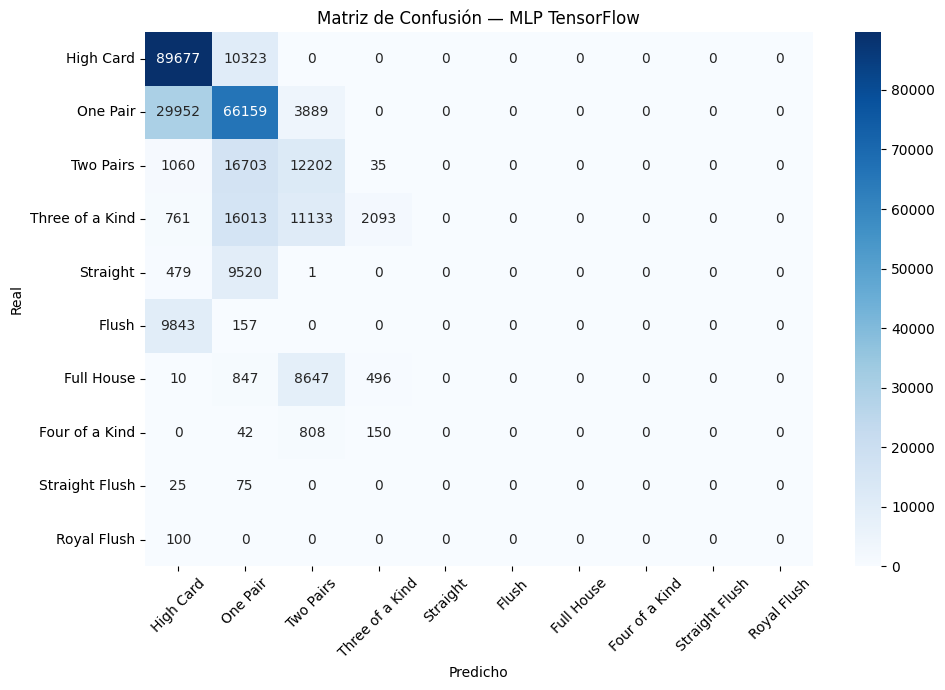

In [6]:
from tensorflow import keras

# Se lee el dataset preprocesado
df = pd.read_csv('../preprocesamiento/preprocessed_trainning.data', header=None)

# Todas las columnas excepto la última
# Última columna
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Número de clases distintas
# Número de características (features) por muestra
n_clases = len(np.unique(y))
n_features = x.shape[1]


modelo_tf = keras.Sequential([    
    # Capa de entrada: recibe vectores de tamaño n_features
    keras.layers.Input(shape=(n_features,)),
    # Primera capa oculta con 64 neuronas y activación ReLU
    keras.layers.Dense(64, activation='relu'),
    # Segunda capa oculta con 32 neuronas y activación ReLU
    keras.layers.Dense(32, activation='relu'),
    # Capa de salida:
    # n_clases neuronas (una por clase)
    # softmax convierte las salidas en probabilidades
    keras.layers.Dense(n_clases, activation='softmax')
])

# Compilación del modelo:
modelo_tf.compile(
    optimizer='adam',  # algoritmo de optimización
    loss='sparse_categorical_crossentropy',  
    # Se usa porque y NO está en one-hot, sino como etiquetas enteras
    metrics=['accuracy']  # métrica de evaluación
)

# Muestra un resumen del modelo (capas, parámetros, etc.)
modelo_tf.summary()


history = modelo_tf.fit(
    x, y,
    epochs=50,          # número de iteraciones completas sobre el dataset
    batch_size=32,      # tamaño de lote
    validation_split=0.2,  # 20% de los datos se usan para validación
    verbose=1           # muestra progreso en consola
)

# Predicciones del modelo (probabilidades por clase)
y_pred_tf = np.argmax(modelo_tf.predict(x), axis=1)

# Se usa argmax para convertir probabilidades en la clase con mayor valor


# Accuracy: proporción de aciertos
print(f"Accuracy : {accuracy_score(y, y_pred_tf):.4f}")
# Recall macro: promedio del recall por clase (útil en datasets desbalanceados)
print(f"Recall   : {recall_score(y, y_pred_tf, average='macro', zero_division=0):.4f}")
# F1-score macro: balance entre precisión y recall por clase
print(f"F1       : {f1_score(y, y_pred_tf, average='macro', zero_division=0):.4f}")


# Calcula la matriz de confusión
cm_tf = confusion_matrix(y, y_pred_tf)

# Se grafica con seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_tf, 
    annot=True,        # muestra números dentro de cada celda
    fmt='d',           # formato entero
    cmap='Blues',      # esquema de colores
    xticklabels=nombres_ordenados,
    yticklabels=nombres_ordenados,
)

# Etiquetas del gráfico
plt.title("Matriz de Confusión — MLP TensorFlow")
plt.xlabel("Predicho")
plt.ylabel("Real")

# Ajustes visuales
plt.tick_params(axis='x', rotation=45)
plt.tick_params(axis='y', rotation=0)
plt.tight_layout()

# Mostrar gráfico
plt.show()